# Introduction to Deep Learning '26 Assignment A0

Paul Tielens, s3612031

In [1]:
import torch
import numpy as np

print(torch.cuda.is_available()) 
print(torch.cuda.device_count()) 
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 4060


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

In [3]:
# constants

nr_digits = 10

data_folder = "data/"

In [4]:
# Load data
train_in = np.loadtxt(data_folder + "train_in.csv", delimiter=",")
train_out = np.loadtxt(data_folder + "train_out.csv", delimiter=",")

test_out = np.loadtxt(data_folder + "test_out.csv", delimiter=",")
test_in = np.loadtxt(data_folder + "test_in.csv", delimiter=",")


In [5]:
values, counts = np.unique(test_out, return_counts=True)
for value, count in zip(values, counts):
    print(f"{int(value)}: {count}")

print()
values, counts = np.unique(train_out, return_counts=True)
for value, count in zip(values, counts):
    print(f"{int(value)}: {count}")


# train and test data is a bit unbalanced

0: 224
1: 121
2: 101
3: 79
4: 86
5: 55
6: 90
7: 64
8: 92
9: 88

0: 319
1: 252
2: 202
3: 131
4: 122
5: 88
6: 151
7: 166
8: 144
9: 132


# Task 1.1

We would expect that digits with similar average vectors would be the most difficult to separate

In [6]:
# Calculate average vector for every digit from the training data

avg_vectors = []

for i in range(nr_digits):
    indices = np.where(train_out == i)

    vectors_i = train_in[indices]
    avg_vector_i = np.mean(vectors_i, axis=0)

    avg_vectors.append(avg_vector_i)

avg_vectors = np.array(avg_vectors)

In [7]:
# Classify the digits based on the distance between the average vector and the test vector

predictions = []

for test_in_element in test_in:
    distances = []
    for i in range(nr_digits):
        dist = np.linalg.norm(avg_vectors[i] - test_in_element)
        distances.append(dist)

    # Take the index of the digit with the lowest 'distance'
    predictions.append(np.argmin(distances))

vector_avg_accuracy = (test_out == predictions).mean() 

print(vector_avg_accuracy)

0.804


In [51]:
distances

[7.056003201381577,
 18.366387912562647,
 13.977376543214604,
 13.763693243134341,
 15.421383283440072,
 12.56391300445845,
 12.241613396517652,
 16.600780610952654,
 14.632670359904974,
 16.059403007678693]

## Distance Matrix

/tmp/ipykernel_3056726/1124406163.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


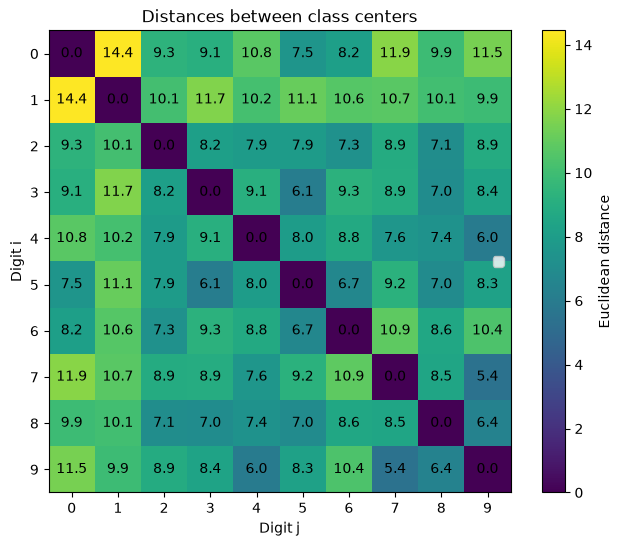

In [83]:
dist_matrix = np.zeros((nr_digits, nr_digits))

for c_i in range(0, nr_digits - 1): # loop over 10 digit averages
    for c_j in range(c_i + 1, nr_digits):
        
        distance = np.linalg.norm(avg_vectors[c_i] - avg_vectors[c_j])
        dist_matrix[c_i][c_j] = distance
        dist_matrix[c_j][c_i] = distance
# create plot
plt.figure(figsize=(8,6))
plt.imshow(dist_matrix, cmap="viridis")
plt.colorbar(label="Euclidean distance")

for i in range(nr_digits):
    for j in range(nr_digits):
        plt.text(j, i, f"{dist_matrix[i, j]:.1f}", ha="center", va="center", fontsize=10)

plt.xticks(range(nr_digits))
plt.yticks(range(nr_digits))
plt.xlabel("Digit j")
plt.ylabel("Digit i")
plt.title("Distances between class centers")
plt.legend()
plt.savefig("plots/distance_matrix_digit_centers.png")
plt.show()



# Task 1.2: dimensionality reduction

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

/home/s3611957/idl_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
train_in.shape

(1707, 256)

## PCA

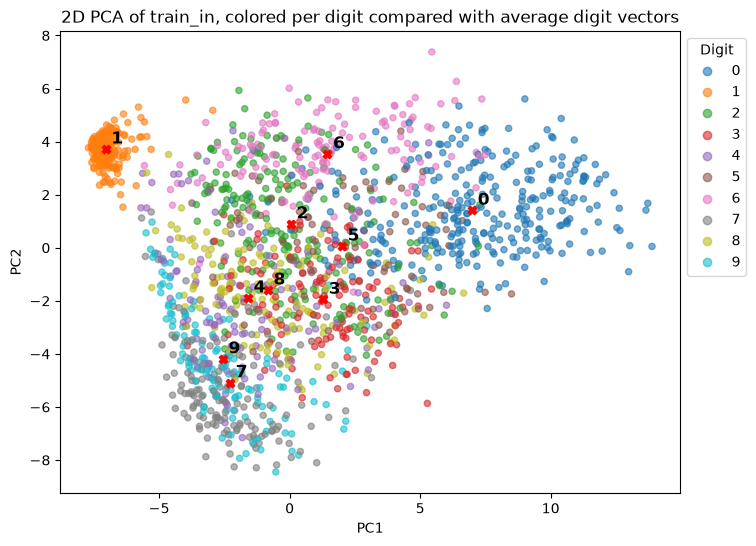

In [41]:
pca = PCA(n_components=2, random_state=42)
train_pca = pca.fit_transform(train_in)
avg_train_pca = pca.transform(avg_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_train_pca[:, 0], avg_train_pca[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_train_pca[n, 0], avg_train_pca[n, 1]),
    xytext=(4, 4), textcoords="offset points", fontsize=12, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/pca_digits.png")
plt.show()



## t-SNE

In [21]:
combined_data = np.vstack([train_in, avg_vectors])
combined_data.shape
print(combined_data.dtype)

float64


In [22]:
avg_vectors.shape

(10, 256)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1717 samples in 0.000s...
[t-SNE] Computed neighbors for 1717 samples in 0.045s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1717
[t-SNE] Computed conditional probabilities for sample 1717 / 1717
[t-SNE] Mean sigma: 2.680450
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.323868
[t-SNE] KL divergence after 1000 iterations: 0.993696


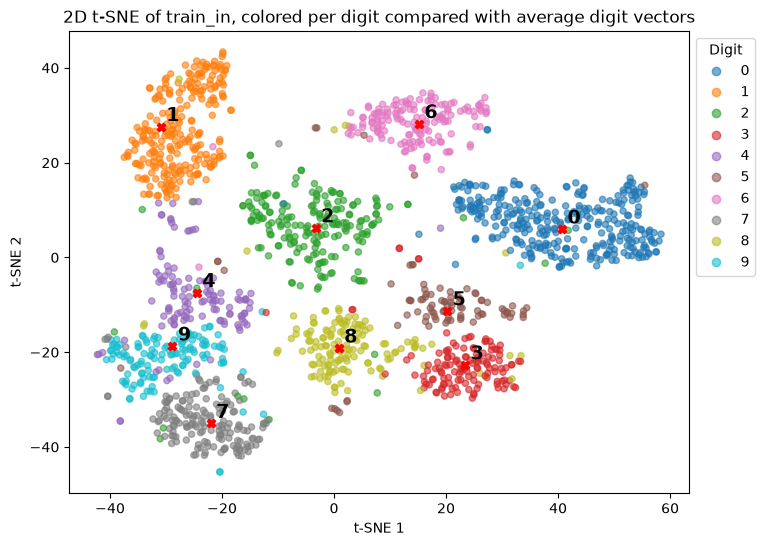

In [43]:
from threadpoolctl import threadpool_limits
# combined_data = np.vstack([train_in, avg_vectors])

tsne = TSNE(n_components=2, random_state=42, n_jobs=1, verbose=1)
with threadpool_limits(limits=1):
    combined_tsne = tsne.fit_transform(combined_data)

train_tsne = combined_tsne[:len(train_in)]
avg_tsne = combined_tsne[len(train_in):]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_tsne[:, 0], train_tsne[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_tsne[:, 0], avg_tsne[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_tsne[n, 0], avg_tsne[n, 1]), 
                 xytext=(4, 4), textcoords="offset points",fontsize=14, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("2D t-SNE of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/tsne_digits.png")
plt.show()




## U-MAP

/home/s3611957/idl_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


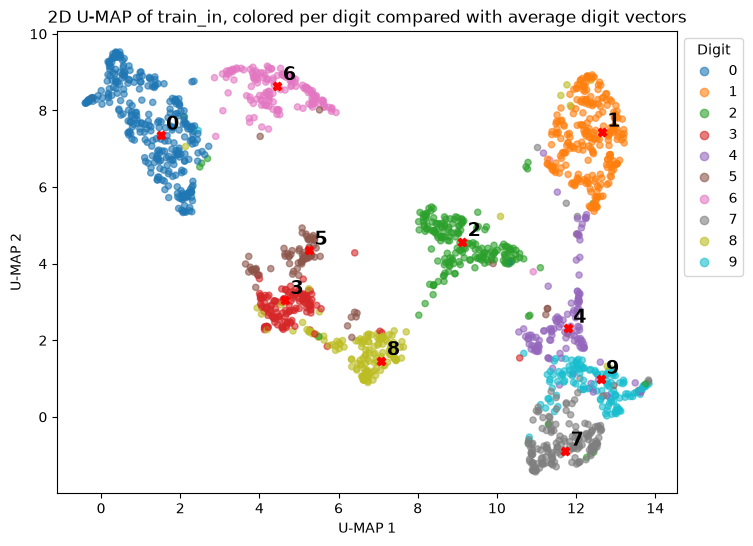

In [44]:
reducer = umap.UMAP(random_state=42)

with threadpool_limits(limits=1):
    train_umap = reducer.fit_transform(train_in)
    avg_umap = reducer.transform(avg_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_umap[:, 0], train_umap[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_umap[:, 0], avg_umap[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_umap[n, 0], avg_umap[n, 1]),
    xytext=(4, 4), textcoords="offset points", fontsize=14, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("U-MAP 1")
plt.ylabel("U-MAP 2")
plt.title("2D U-MAP of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/umap_digits.png")
plt.show()
